In [110]:
#Importation des package
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [111]:
# Supprimer les warning
import warnings
warnings.filterwarnings("ignore")

In [112]:
#Monter le drive
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [113]:
#Charger les données
df = pd.read_csv('/content/drive/MyDrive/DSI-WS-ML-20260310T185908Z-3-001/DSI-WS-ML/2-Supervised Learning/Classification/Doc 1/Car_Data.csv')

## 1- Exploration des données

In [114]:
#Afficher les données
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant


In [115]:
# Afficher les informations sur les données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507 entries, 0 to 5506
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Marque           5507 non-null   object
 1   Année            5507 non-null   int64 
 2   Boite_Vitesse    5507 non-null   object
 3   Adresse          5507 non-null   object
 4   Prix             5507 non-null   int64 
 5   Venant_Occasion  5507 non-null   object
dtypes: int64(2), object(4)
memory usage: 258.3+ KB


In [116]:
# Afficher les dimensions du jeux de données
df.shape

(5507, 6)

In [117]:
df["Venant_Occasion"].unique()

array(['Venant', "D'occasion"], dtype=object)

In [118]:
# Description des données quali
df.describe(include='object').T

,count,unique,top,freq
Marque,5507,46,Ford,1391
Boite_Vitesse,5507,3,Automatique,4675
Adresse,5507,182,"Almadies,Dakar",765
Venant_Occasion,5507,2,Venant,2855


In [119]:
#description des données quanti
df.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
Année,5507.0,2.014508e+03,3.089839e+00,1990.0,2013.0,2015.0,2016.0,2024.0
Prix,5507.0,1.110512e+07,1.619639e+07,1.0,4600000.0,7800000.0,12500000.0,779414131.0


In [120]:
#Description des données quanti et quali
df.describe(include='all')

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion
count,5507,5507.000000,5507,5507,5.507000e+03,5507
unique,46,NaN,3,182,NaN,2
top,Ford,NaN,Automatique,"Almadies,Dakar",NaN,Venant
freq,1391,NaN,4675,765,NaN,2855
mean,NaN,2014.508444,NaN,NaN,1.110512e+07,NaN
std,NaN,3.089839,NaN,NaN,1.619639e+07,NaN
min,NaN,1990.000000,NaN,NaN,1.000000e+00,NaN
25%,NaN,2013.000000,NaN,NaN,4.600000e+06,NaN
50%,NaN,2015.000000,NaN,NaN,7.800000e+06,NaN
75%,NaN,2016.000000,NaN,NaN,1.250000e+07,NaN


## 2- Traitement des données

In [121]:
#Spliter l'adress en quartier et ville

df[["Quartiers", "Villes"]] = df.Adresse.str.split(",",n=1,expand=True)
df.head()

,Marque,Année,Boite_Vitesse,Adresse,Prix,Venant_Occasion,Quartiers,Villes
0,Mitsubishi,2017,Automatique,"Liberte 6,Dakar",9750000,Venant,Liberte 6,Dakar
1,Ford,2009,Manuelle,"Yoff,Dakar",2500000,D'occasion,Yoff,Dakar
2,BMW,2015,Automatique,"Cité Damel,Dakar",15500000,D'occasion,Cité Damel,Dakar
3,Ford,2013,Automatique,"Almadies,Dakar",3800000,D'occasion,Almadies,Dakar
4,GMC,2014,Automatique,"Hlm,Dakar",7500000,Venant,Hlm,Dakar


In [122]:
#Supprimer les colonnes Adresse et villes
df.drop(["Adresse", "Villes"],axis=1, inplace=True)


In [123]:
#Afficher les données après suppression des colonnes non pertinantes
df.head()

,Marque,Année,Boite_Vitesse,Prix,Venant_Occasion,Quartiers
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,D'occasion,Yoff
2,BMW,2015,Automatique,15500000,D'occasion,Cité Damel
3,Ford,2013,Automatique,3800000,D'occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [124]:
#Afficher les valeur unique de quartier
list(np.unique(df.Quartiers))

[' Almadies',
 ' Almadies 2',
 ' Avenue Bourguiba',
 ' Bambilor',
 ' Castor',
 ' Cité Damel',
 ' Cité keur gorgui',
 ' Colobane',
 ' Fann',
 ' Fenêtre mermoz',
 ' Golf',
 ' Grand-Dakar',
 ' Guediawaye',
 ' Hann maristes',
 ' Hlm',
 ' Hlm grand-yoff',
 ' Keur Massar',
 ' Liberte 6',
 ' Liberte 6 extension',
 ' Mbao',
 ' Mermoz',
 ' Médina',
 ' Ngor',
 ' Nord foire',
 ' Ouakam',
 ' Ouest foire',
 ' Parcelles Assainies',
 ' Pikine',
 ' Plateau',
 ' Rufisque',
 ' Sacré-cœur',
 ' Sicap Liberté',
 ' Sicap foire',
 ' VDN',
 ' Virage',
 ' Yoff',
 'Almadies',
 'Almadies 2',
 'Amitié',
 'Avenue Bourguiba',
 'Bambilor',
 'Bargny',
 'Bel air',
 'Biscuiterie',
 'Cambérène',
 'Castor',
 'Cite Mixta',
 'Cité Damel',
 'Cité asecna',
 'Cité assemblée',
 'Cité avion',
 'Cité biagui',
 'Cité keur gorgui',
 'Colobane',
 'Comico',
 'Dalifort',
 'Derkle',
 'Diamaguene',
 'Diamniadio',
 'Dieuppeul',
 'Djily mbaye',
 'Fann',
 'Fann Hock',
 'Fenêtre mermoz',
 'Gibraltar',
 'Golf',
 'Gorée',
 'Grand-Dakar',
 'G

In [125]:
#Gérer les espace sur la variable quartier

df.Quartiers = df.Quartiers.str.strip()

In [126]:
#Variable unique Venant_Occasion
np.unique(df["Venant_Occasion"])

array(["D'occasion", 'Venant'], dtype=object)

In [127]:
#Remplacer D'occasion en Occasion
df.Venant_Occasion = df.Venant_Occasion.replace("D'occasion", "Occasion")

In [128]:
df.head()

,Marque,Année,Boite_Vitesse,Prix,Venant_Occasion,Quartiers
0,Mitsubishi,2017,Automatique,9750000,Venant,Liberte 6
1,Ford,2009,Manuelle,2500000,Occasion,Yoff
2,BMW,2015,Automatique,15500000,Occasion,Cité Damel
3,Ford,2013,Automatique,3800000,Occasion,Almadies
4,GMC,2014,Automatique,7500000,Venant,Hlm


In [129]:
df.describe(include='object')

,Marque,Boite_Vitesse,Venant_Occasion,Quartiers
count,5507,5507,5507,5507
unique,46,3,2,86
top,Ford,Automatique,Venant,Almadies
freq,1391,4675,2855,792


In [130]:
np.unique(df["Venant_Occasion"])

array(['Occasion', 'Venant'], dtype=object)

In [131]:
#Renommer les colonne Venant_Occasion en Etat et Boite_Vitesse en Transmission
df = df.rename(columns={"Boite_Vitesse":"Transmission","Venant_Occasion":"Etat"})

In [132]:
df.columns

Index(['Marque', 'Année', 'Transmission', 'Prix', 'Etat', 'Quartiers'], dtype='object')

In [133]:
#Reorganiser les colonne pour afficher l'état, la prévision à la fin
df = df[['Marque', 'Année', 'Transmission', 'Quartiers', 'Prix', 'Etat']]
df.head()

,Marque,Année,Transmission,Quartiers,Prix,Etat
0,Mitsubishi,2017,Automatique,Liberte 6,9750000,Venant
1,Ford,2009,Manuelle,Yoff,2500000,Occasion
2,BMW,2015,Automatique,Cité Damel,15500000,Occasion
3,Ford,2013,Automatique,Almadies,3800000,Occasion
4,GMC,2014,Automatique,Hlm,7500000,Venant


## 3- Visualisation et encodage des variables

In [134]:
# Variable catégorielle
cat_data = df.select_dtypes(include='object')
cat_data.head()

,Marque,Transmission,Quartiers,Etat
0,Mitsubishi,Automatique,Liberte 6,Venant
1,Ford,Manuelle,Yoff,Occasion
2,BMW,Automatique,Cité Damel,Occasion
3,Ford,Automatique,Almadies,Occasion
4,GMC,Automatique,Hlm,Venant


In [135]:
import joblib as jb
# Enregistrer les valeurs des variables catégorielles dans un objet joblib
uniques = [] # listes des listes des valeurs uniques de chaque variable catégorielle
for col in cat_data.columns:
  uniques.append(list(np.unique(df[col])))

In [136]:
# faire un dumping de la liste des valeurs uniques
jb.dump(uniques, 'uniques.joblib')

['uniques.joblib']

In [137]:
import seaborn as sns
import plotly.express as px

In [138]:
# fonction de countplot
def countplot_func(col):
  val = df[col].value_counts()
  plt.figure(figsize=(25,3))
  fig = px.bar(x=val.index, y=val.values, color = val.index.astype(str), text_auto=True)
  fig.show()

In [139]:
# Countplots de toutes les variables
for col in cat_data.columns:
  countplot_func(col)

<Figure size 2500x300 with 0 Axes>

<Figure size 2500x300 with 0 Axes>

<Figure size 2500x300 with 0 Axes>

<Figure size 2500x300 with 0 Axes>

In [140]:
#Exploration de variable quanti
quant_data = df.select_dtypes(include='number')
quant_data.head()

,Année,Prix
0,2017,9750000
1,2009,2500000
2,2015,15500000
3,2013,3800000
4,2014,7500000


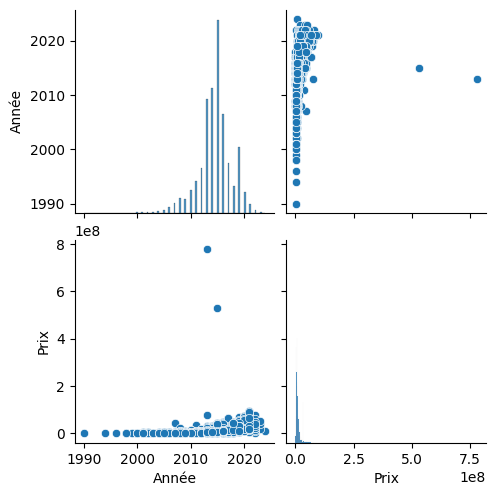

In [141]:
#Faire un paiplot pour les données quantitatives
sns.pairplot(quant_data)
plt.show()

In [142]:
#La matrice de corrélation
quant_data.corr()

,Année,Prix
Année,1.000000,0.399623
Prix,0.399623,1.000000


In [143]:
# fonction boxplots
def boxplot_func(col):
  plt.figure(figsize=(25,3))
  sns.boxplot(x=df[col])
  plt.show()

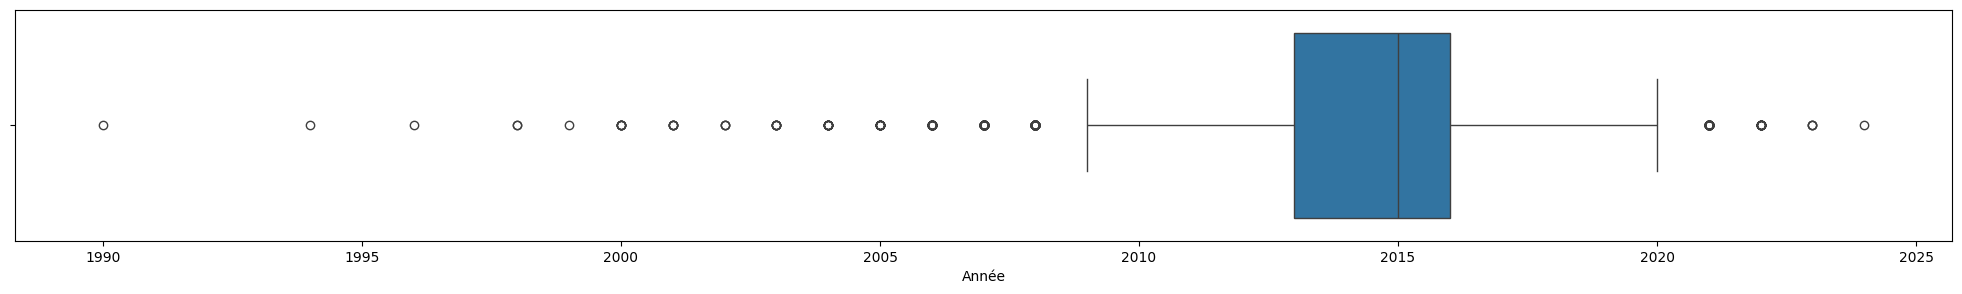

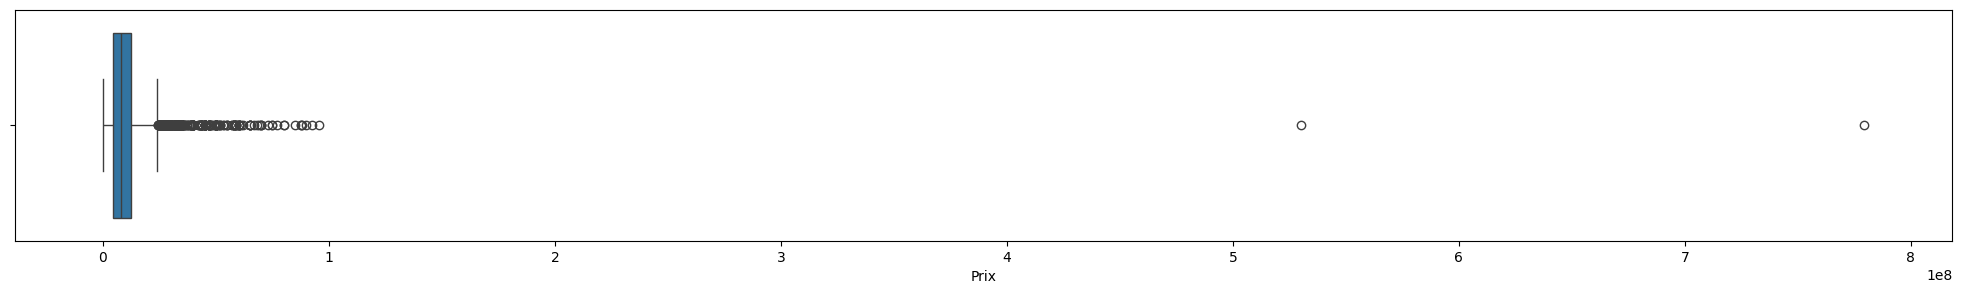

In [144]:
# boxplots des toutes les variables quantitatives
for col in quant_data.columns:
  boxplot_func(col)

## 4- Fractionnement, normalisation et splitement des données

In [145]:
# Importer le modèle LabelEncoder
from sklearn.preprocessing import LabelEncoder

#1ère méthode
# instantier la classe LabelEncoder
#encoder = LabelEncoder()
# Encoder les variables catégorielles
#for col in cat_data:
# df[col] = encoder.fit_transform(df[col])

#2ème méthode
encoder0 = LabelEncoder() # objet encoder pour la variable marque
encoder1 = LabelEncoder() # objet encoder pour la variable transmission
encoder2 = LabelEncoder() # objet encoder pour la variable quartiers
encoder3 = LabelEncoder() # objet encoder pour la variable etat
encoders = [encoder0, encoder1, encoder2, encoder3]

for i in range(len(cat_data.columns)):
    encoders[i] = LabelEncoder()
    df[cat_data.columns[i]] = encoders[i].fit_transform(df[cat_data.columns[i]])

df.head()

,Marque,Année,Transmission,Quartiers,Prix,Etat
0,30,2017,0,49,9750000,1
1,13,2009,1,83,2500000,0
2,3,2015,0,11,15500000,0
3,13,2013,0,0,3800000,0
4,14,2014,0,38,7500000,1


In [146]:
# télécharger les encodeurs en utilisant joblib
import joblib as jb
# sauvegarder les encodeur
jb.dump(encoders, 'encoders.joblib')

['encoders.joblib']

In [147]:
# Fractionner les données en X (Variables prédicteurs) et y (Variable cible)
x =df.drop(['Etat'], axis = 1).values # matrice des variables d'entrées
y = df.Etat.values # vecteur de la variable de sortie
x[:5],y[:5]

(array([[      30,     2017,        0,       49,  9750000],
        [      13,     2009,        1,       83,  2500000],
        [       3,     2015,        0,       11, 15500000],
        [      13,     2013,        0,        0,  3800000],
        [      14,     2014,        0,       38,  7500000]]),
 array([1, 0, 0, 0, 1]))

In [148]:
# importer StandardScaler
from sklearn.preprocessing import StandardScaler
# Instancier StandardScaler
scaler = StandardScaler()
scaler.fit(x) # calcul de la moyenne et de l'écart type
x = scaler.transform(x) # normalisation x = x- mean(x)/std(x)
x[:5]

array([[ 0.85878423,  0.80644413, -0.41901075,  0.23385467, -0.08367563],
       [-0.75664949, -1.78292272,  2.32147882,  1.49158088, -0.5313469 ],
       [-1.70690462,  0.15910242, -0.41901075, -1.17183933,  0.271374  ],
       [-0.75664949, -0.4882393 , -0.41901075, -1.57875075, -0.45107481],
       [-0.66162398, -0.16456844, -0.41901075, -0.17305675, -0.22260809]])

In [149]:
# faire un dumping (télécharger ou sauvegarder) du normaliseur
jb.dump(scaler, 'scaler.joblib')

['scaler.joblib']

In [150]:
# Splitter les données
from sklearn.model_selection import train_test_split
# train (80%), val(10%) et test(10%)
#train : données d'entrainement, val: données utiliser pour évaluer chaque modèle et test: données pour tester le modèle le plus performant
x_train, x_vt, y_train, y_vt = train_test_split(x,y, test_size = 0.2, random_state = 42) # Splitter le dataset en 80%/20%-
#x_train, x_vt, y_train, x_vt = train_test_split(x,y,train_size = 0.8, random_state = 42)
x_val,x_test, y_val, y_test = train_test_split(x_vt, y_vt, train_size = 0.5, random_state = 42) # spliter x_vt en 10% / 10%


In [151]:
# Afficher les dimensions X_train, y_train
x_train[:5], y_train[:5]

(array([[ 0.6687332 ,  1.45378584, -0.41901075, -1.57875075,  1.35195982],
        [ 1.14386077, -1.78292272, -0.41901075,  0.78873388, -0.4263757 ],
        [ 0.57370769, -0.16456844, -0.41901075,  0.93670167, -0.09911257],
        [-0.75664949,  0.80644413, -0.41901075,  1.34361309,  0.17875236],
        [ 1.33391179, -0.16456844, -0.41901075, -1.28281517,  0.91972549]]),
 array([1, 0, 0, 1, 0]))

In [152]:
# Afficher les dimmensions
x_train.shape, y_train.shape

((4405, 5), (4405,))

In [153]:
# Afficher les dimensions X_test, y_test
x_test.shape, y_test.shape

((551, 5), (551,))

In [154]:
# Afficher les dimensions X_val, y_val
x_val.shape, y_val.shape

((551, 5), (551,))

## 5- Modelisation

### <font color = 'bisque'>*5-1 K nearest neighbor (K-NN)*

In [155]:
# Importer KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier

In [156]:
# importer GridSearchCV
from sklearn.model_selection import GridSearchCV
# initialiser le modèle knn
knn = KNeighborsClassifier()
# # créer le dictionnaire params
params_dic = {'n_neighbors': list(range(2, 31))} #Valeur Max Racine carré de la valeur d'observation
# Instantier le modèle GridSearchCV
grid = GridSearchCV(knn, params_dic, cv =5) # folds-groupes = a,b,c,d,e
# lancer la recherche
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,
                                         14, 15, 16, 17, 18, 19, 20, 21, 22, 23,
                                         24, 25, 26, 27, 28, 29, 30]})

In [157]:
# k optimal
n_neighbors_optimal = grid.best_params_['n_neighbors']
# Instantier le modèle
knn_best_model = KNeighborsClassifier(n_neighbors = n_neighbors_optimal)
# Entrainer le modèle
knn_best_model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=28)

In [158]:
# echantilon de 10
x_test_10 = x_test[10:20]
y_test_10 = y_test[10:20]
class_names = ["Occasion", "venante"]
# prédictions
y_pred_10 = knn_best_model.predict(x_test_10)
# Afficher les prédictions
for i in range(10):
    print(f"La voiture {str(i+1)} est une voiture {class_names[y_pred_10[i]]} --- {class_names[y_test_10[i]]} ")

La voiture 1 est une voiture venante --- Occasion 
La voiture 2 est une voiture venante --- venante 
La voiture 3 est une voiture venante --- venante 
La voiture 4 est une voiture Occasion --- Occasion 
La voiture 5 est une voiture Occasion --- Occasion 
La voiture 6 est une voiture Occasion --- venante 
La voiture 7 est une voiture Occasion --- Occasion 
La voiture 8 est une voiture Occasion --- venante 
La voiture 9 est une voiture Occasion --- Occasion 
La voiture 10 est une voiture Occasion --- Occasion 


In [159]:
# Importer accuracy_score
from sklearn.metrics import accuracy_score
# prédictions
y_pred = knn_best_model.predict(x_test)
# calculer l'accuracy
acc_knn = accuracy_score(y_test, y_pred)
# Afficher l'accuracy
print(f"L'accuracy de notre modèle est : {acc_knn: .2f}")

L'accuracy de notre modèle est :  0.77


In [160]:
# Accuracy et F1 score du modèle sur les données de validation
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
def evaluation(model):
  y_pred = model.predict(x_val)
  acc = accuracy_score(y_val, y_pred)
  f1 = f1_score(y_val, y_pred, average='micro')
  prec = precision_score(y_val, y_pred, average='micro')
  rec = recall_score(y_val, y_pred, average='micro')
  return acc, f1,prec, rec

In [161]:
# Afficher les métriques
acc_knn, f1_knn,prec_knn, rec_knn = evaluation(knn_best_model)
print(f"Accuracy : {acc_knn: .2f} -- F1 : {f1_knn: .2f} -- Precision : {prec_knn: .2f} -- Recall : {rec_knn: .2f}")

Accuracy :  0.80 -- F1 :  0.80 -- Precision :  0.80 -- Recall :  0.80


In [162]:
# Importer ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
def heatmap_conf_matr(model):

  # y_pred:  prédictions du modèle sur les données validation
  y_pred = model.predict(x_val)
  # Confusion matrix
  cnf_matr = confusion_matrix(y_val, y_pred, labels=[0,1])

  # Utiliser ConfusionMatrixDisplay pour visualiser la matrice de confusion
  disp = ConfusionMatrixDisplay(confusion_matrix=cnf_matr,
                                display_labels=['Occasion','Venant'])
  disp.plot() # Afficher la matrice de confusion
  plt.title('Matrice de confusion') # Définir le titre
  plt.show() # Afficher la figure

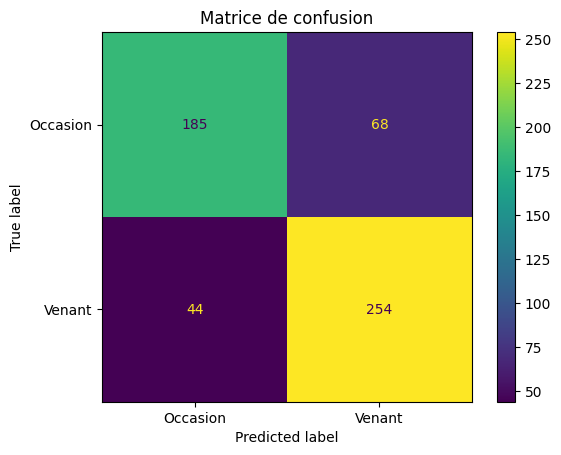

In [163]:
# visualiser
heatmap_conf_matr(knn_best_model)

### <font color = 'bisque'>*5-2 Random Forest*

In [164]:
# Recherche des paramètres optimaux pour le Random Forest
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
# dictionnaire des  params
params = param_grid = {
    'n_estimators': list(np.arange(10,100,10)),
    'max_depth' : list(np.arange(3,15)),
    'criterion' :['gini', 'entropy']
}
# instantier le modèle Random Forest
rf = RandomForestClassifier()
# instantier le modèle gridsearch
grid = GridSearchCV(estimator=rf, param_grid=params, cv= 5)
# entrainer le modèle
grid.fit(x_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [165]:
# Afficher les paramètres optimaux
grid.best_params_

{'criterion': 'gini', 'max_depth': np.int64(9), 'n_estimators': np.int64(90)}

In [166]:
from sklearn.ensemble import RandomForestClassifier
# Entrainer Random Forest en utilisant les paramètres optimaux
rf_model = RandomForestClassifier(n_estimators=70, max_depth =8 , criterion =  'entropy')
rf_model.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', max_depth=8, n_estimators=70)

### Evaluation du model RandomForest

In [167]:
# Accuracy et F1 score du modèle sur les données de validation
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
def evaluation(model):
  y_pred = model.predict(x_val)
  acc = accuracy_score(y_val, y_pred)
  f1 = f1_score(y_val, y_pred, average='micro')
  prec = precision_score(y_val, y_pred, average='micro')
  rec = recall_score(y_val, y_pred, average='micro')
  return acc, f1,prec, rec

In [168]:
# Afficher les métriques
acc_rf, f1_rf,prec_rf, rec_rf = evaluation(rf_model)
print(f"Accuracy : {acc_rf: .2f} -- F1 : {f1_rf: .2f} -- Precision : {prec_rf: .2f} -- Recall : {rec_rf: .2f}")

Accuracy :  0.81 -- F1 :  0.81 -- Precision :  0.81 -- Recall :  0.81


In [169]:
# Accuracy sur les données train
y_pred_train = rf_model.predict(x_train)
print(f"F1 score sur les données train : {f1_score(y_train, y_pred_train, average = 'micro'): .2f}")

F1 score sur les données train :  0.85


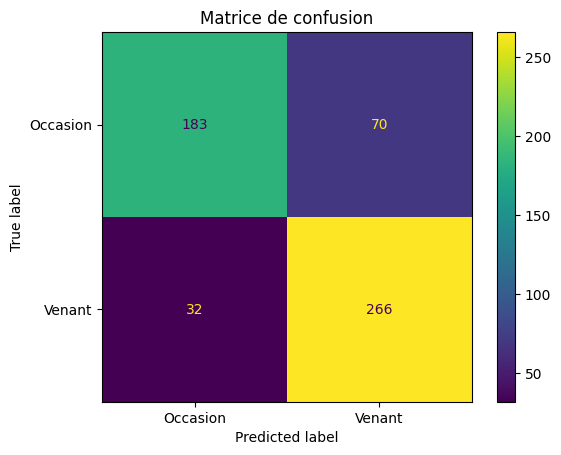

In [170]:
# visualiser
heatmap_conf_matr(rf_model)

In [171]:
# fonction de visualisation du diagramme des features importances
def bar_feat_imp(model):
  fig = px.bar( x = model.feature_importances_, y = df.columns[:-1])
  fig.show()

In [172]:
# barplot de l'importance des variables
bar_feat_imp(rf_model)

### <font color = 'bisque'>*5-3 Gradient Booster*

In [ ]:
# Recherche des paramètres optimaux pour Gradient Boosting
from sklearn.ensemble import GradientBoostingClassifier
# dictionnaire des params
params_ = { "n_estimators":list(np.arange(10,100,10)),
              "max_depth":list(np.arange(3,15))}
# instantier le modèle Gradient Boost
gb = GradientBoostingClassifier()
# instantier le modèle gridsearch
grid_ = GridSearchCV(estimator=gb, param_grid=params_)
# entrainer le modèle
grid_.fit(x_train, y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'max_depth': [np.int64(3), np.int64(4), np.int64(5),
                                       np.int64(6), np.int64(7), np.int64(8),
                                       np.int64(9), np.int64(10), np.int64(11),
                                       np.int64(12), np.int64(13),
                                       np.int64(14)],
                         'n_estimators': [np.int64(10), np.int64(20),
                                          np.int64(30), np.int64(40),
                                          np.int64(50), np.int64(60),
                                          np.int64(70), np.int64(80),
                                          np.int64(90)]})

In [ ]:
# afficher les paramètres optimaux
grid_.best_params_

{'max_depth': np.int64(5), 'n_estimators': np.int64(40)}

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
# Entrainer Gradient Boosting en utilisant les paramètres optimaux max_depth = 5, n_estimators = 50
gb_model = GradientBoostingClassifier(max_depth= 5, n_estimators = 40)
gb_model.fit(x_train, y_train)

GradientBoostingClassifier(max_depth=5, n_estimators=40)

## Evaluation du Gradient Booster

In [ ]:
# Afficher les métriques
acc_gb, f1_gb,prec_gb, rec_gb = evaluation(gb_model)
print(f"Accuracy : {acc_gb: .2f} -- F1 : {f1_gb: .2f} -- Precision : {prec_gb: .2f} -- Recall : {rec_gb: .2f}")

Accuracy :  0.82 -- F1 :  0.82 -- Precision :  0.82 -- Recall :  0.82


In [ ]:
# Accuracy sur les données train
y_pred_train = gb_model.predict(x_train)
print(f"F1 score sur les données train : {f1_score(y_train, y_pred_train, average = 'micro'): .2f}")

F1 score sur les données train :  0.85


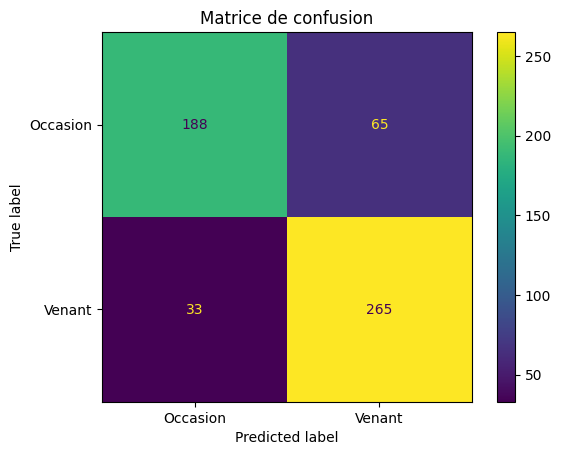

In [ ]:
# matrice de confusion
heatmap_conf_matr(gb_model)

In [ ]:
# barplot de l'importance des variables
bar_feat_imp(gb_model)

### <font color = 'bisque'>*5-4 XGBoost*

In [ ]:
from sklearn.model_selection import GridSearchCV
# Recherche des paramètres optimaux pour XGBoost
from xgboost import XGBClassifier
# dictionnaire des params
params__ = {  "n_estimators":list(np.arange(10,100,10)),
              "max_depth":list(np.arange(3,15))}
# instantier le modèle XGBoost
xgb = XGBClassifier()
# instantier le modèle gridsearch
grid__ = GridSearchCV(estimator=xgb, param_grid=params__, cv= 5)
# entrainer le modèle
grid__.fit(x_train, y_train)

In [ ]:
# afficher les paramètres optimaux
grid__.best_params_

{'max_depth': np.int64(4), 'n_estimators': np.int64(70)}

In [ ]:
# Entrainer le modèle en utilisant les paramètres optimaux
xgb_model = XGBClassifier(n_estimators = 70, max_depth =4 )
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=70,
              n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# Afficher les métriques
acc_xgb, f1_xgb,prec_xgb, rec_xgb = evaluation(xgb_model)
print(f"Accuracy : {acc_xgb: .2f} -- F1 : {f1_xgb: .2f} -- Precision : {prec_xgb: .2f} -- Recall : {rec_xgb: .2f}")

Accuracy :  0.84 -- F1 :  0.84 -- Precision :  0.84 -- Recall :  0.84


In [ ]:
# Accuracy sur les données train
y_pred_train = xgb_model.predict(x_train)
print(f"F1 score sur les données train : {f1_score(y_train, y_pred_train, average = 'micro'): .2f}")

F1 score sur les données train :  0.86


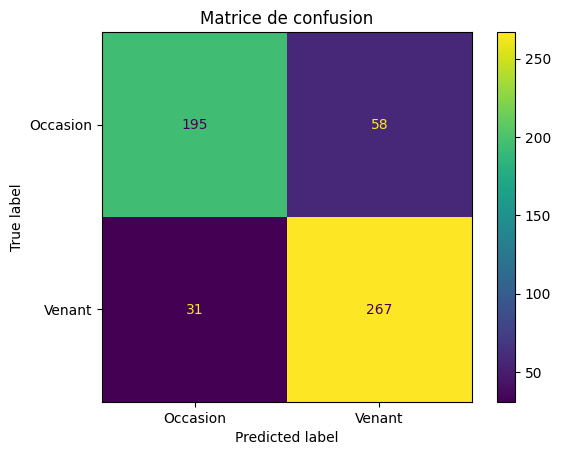

In [ ]:
# matrice de confusion
heatmap_conf_matr(xgb_model)

In [ ]:
# barplot de l'importance des variables
bar_feat_imp(xgb_model)

## 6- Choix du model le plus performant

In [ ]:
# Diagramme en barre de comparaison des modèles
list_f1 = [f1_knn,f1_rf, f1_gb, f1_xgb]
list_acc = [acc_knn,acc_rf, acc_gb, acc_xgb]
list_prec = [prec_knn,prec_rf, prec_gb, prec_xgb]
list_rec = [rec_knn,rec_rf, rec_gb, rec_xgb]
list_models = ['KNN','RF', 'GB', 'XGB']
all_lists = [list_f1, list_acc, list_prec, list_rec]
metrics_names = ['F1-score', 'Accuracy', 'Precision', 'Recall']
for i in range(4):
  fig= px.bar(x = list_models, y = all_lists[i], color = list_models, title = metrics_names[i], text_auto=True)

  fig.show()

In [ ]:
# télécharger le modèle le plus performant
jb.dump(xgb_model, 'xgb_model.joblib')

## 7- Tester le model le plus performant

In [ ]:
x_test_10 = x_test[:10]
y_test_10 = y_test[:10]
y_pred_10 = xgb_model.predict(x_test_10)
class_names = ["Occasion", "Venant"]
for i in range(10):
  print(f"Le véhicule {i + 1} est un véhicule {class_names[y_pred_10[i]]} -- {class_names[y_test_10[i]]}")

In [ ]:
#pip install gradio

In [ ]:
df.columns

In [ ]:
# Fonction de prédiction
import gradio as gr
import joblib as jb
# importer les encodeurs
encoders = jb.load('encoders.joblib')
# importer les valeurs uniques
uniques = jb.load('uniques.joblib')
# importer le normaliseur
scaler = jb.load('scaler.joblib')
# importer le modèle
xgb = jb.load('xgb_model.joblib')

# noms des classes
clasnames = uniques[3]
# fonction de prédiction simple
def Pred_func(Marque, Année, Transmission, Quartiers, Prix):
  # Encoder les valeur marque, transmission, quartiers
  Marque = encoders[0].transform([Marque])[0]
  Transmission = encoders[1].transform([Transmission])[0]
  Quartiers = encoders[2].transform([Quartiers])[0]
  # vecteur des valeurs numériques
  x_new = np.array([Marque, Année, Transmission, Quartiers, Prix])
  x_new = x_new.reshape(1,-1) # convert en un 2D array
  # Normaliser les données
  x_new = scaler.transform(x_new)
  # Prédire
  y_pred = xgb.predict(x_new)
  return clasnames[y_pred[0]]

In [ ]:
# Fonction de prédiction multiple
def Pred_func_csv(file):
  # Lire le fichier csv
  df = pd.read_csv(file)
  predictions = []
  # Boucle sur les lignes du dataframe
  for row in df.iloc[:, :].values:
    # prédiction simple
    y_pred = Pred_func(row[0], row[1], row[2], row[3], row[4])
    predictions.append(y_pred)

  df['etat'] = predictions
  df.to_csv('predictions.csv', index = False)
  return 'predictions.csv'

In [ ]:
# définir les blocks
demo = gr.Blocks(theme='JohnSmith9982/small_and_pretty')

# Créer les inputs
inputs = [gr.Dropdown(choices=uniques[0], label='Marque'),
          gr.Number(label='Année'),
          gr.Dropdown(choices=uniques[1], label='Transmission'),
          gr.Dropdown(choices=uniques[2], label='Quartier'),
          gr.Number(label='Prix')
          ]
# Créer les outputs
outputs = gr.Textbox(label='Etat du véhicule')
# Créer l'interface 1
interface1 = gr.Interface(fn = Pred_func,
                         inputs = inputs,
                         outputs = outputs,
                         title="Prédire l'état d'un véhicule avec une entrée",
                         description = """Ce modèle de machine permet de prédire l'état d'un véhicule en partant
                        du prix, de l'année, la marque, du quartier de vente, la transmission et l'état.
                         """)
# Créer l'interface 2
interface2 = gr.Interface(fn = Pred_func_csv,
                         inputs = gr.File(label='Importer un fichier csv'),
                          outputs = gr.File(label='Télécharger un fichier csv'),
                         title="Prédire l'état d'un véhicule avec plusieurs entrées",
                         description = """e modèle de machine permet de prédire l'état d'un véhicule en partant
                        du prix, de l'année, la marque, du quartier de vente, la transmission et l'état.
                         """)

# faire un tabbing des interfaces
with demo:
  gr.TabbedInterface([interface1, interface2], ['Simple Prediction', 'Prédiction multiple'])

# lancer l'interface
demo.launch(share = True)